# Softmax Regression Example

### 生成数据集， 看明白即可无需填写代码
#### '<font color="blue">+</font>' 从高斯分布采样 (X, Y) ~ N(3, 6, 1, 1, 0).<br>
#### '<font color="green">o</font>' 从高斯分布采样  (X, Y) ~ N(6, 3, 1, 1, 0)<br>
#### '<font color="red">*</font>' 从高斯分布采样  (X, Y) ~ N(7, 7, 1, 1, 0)<br>

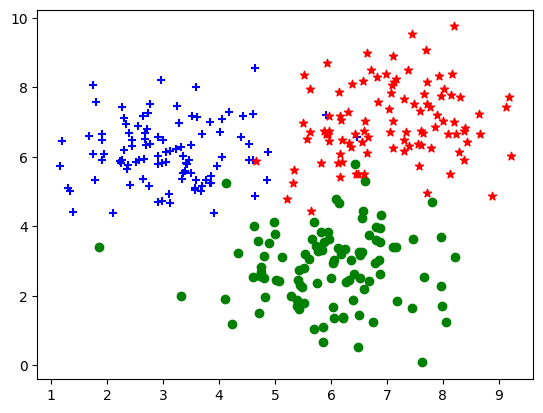

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

dot_num = 100
# 第一类数据
x_p = np.random.normal(3., 1, dot_num)
y_p = np.random.normal(6., 1, dot_num)
y = np.ones(dot_num)
C1 = np.array([x_p, y_p, y]).T

# 第二类数据
x_n = np.random.normal(6., 1, dot_num)
y_n = np.random.normal(3., 1, dot_num)
y = np.zeros(dot_num)
C2 = np.array([x_n, y_n, y]).T

# 第三类数据
x_b = np.random.normal(7., 1, dot_num)
y_b = np.random.normal(7., 1, dot_num)
y = np.ones(dot_num)*2
C3 = np.array([x_b, y_b, y]).T

plt.scatter(C1[:, 0], C1[:, 1], c='b', marker='+')
plt.scatter(C2[:, 0], C2[:, 1], c='g', marker='o')
plt.scatter(C3[:, 0], C3[:, 1], c='r', marker='*')

data_set = np.concatenate((C1, C2, C3), axis=0)
np.random.shuffle(data_set)

## 建立模型
建立模型类，定义loss函数，定义一步梯度下降过程函数

填空一：在`__init__`构造函数中建立模型所需的参数

填空二：实现softmax的交叉熵损失函数(不使用tf内置的loss 函数)

In [5]:
epsilon = 1e-12
class SoftmaxRegression():
    def __init__(self):
        '''============================='''
        # 填空一答案: 构建模型所需的参数 self.W, self.b
        # 输入维度: 2 (x, y坐标)
        # 输出维度: 3 (三个类别)
        '''============================='''
        self.W = tf.Variable(shape=[2, 3], dtype=tf.float32, 
            initial_value=tf.random.uniform(shape=[2, 3], minval=-0.1, maxval=0.1))
        self.b = tf.Variable(shape=[3], dtype=tf.float32, 
            initial_value=tf.zeros(shape=[3]))
        '''============================='''
        
        self.trainable_variables = [self.W, self.b]
    @tf.function
    def __call__(self, inp):
        logits = tf.matmul(inp, self.W) + self.b # shape(N, 3)
        pred = tf.nn.softmax(logits)
        return pred    
    
@tf.function
def compute_loss(pred, label):
    label = tf.one_hot(tf.cast(label, dtype=tf.int32), dtype=tf.float32, depth=3)
    '''============================='''
    # 填空二答案: 实现softmax的交叉熵损失函数
    # 多分类交叉熵损失: L = -sum(y_i * log(p_i))
    # 输入label shape(N, 3), pred shape(N, 3)
    # 输出 losses shape(N,) 每一个样本一个loss
    '''============================='''
    # 添加epsilon防止log(0)
    pred = tf.clip_by_value(pred, epsilon, 1 - epsilon)
    # 计算交叉熵损失: -sum(y_i * log(p_i))
    losses = -tf.reduce_sum(label * tf.math.log(pred), axis=1)
    '''============================='''
    loss = tf.reduce_mean(losses)
    
    accuracy = tf.reduce_mean(tf.cast(tf.equal(tf.argmax(label,axis=1), tf.argmax(pred, axis=1)), dtype=tf.float32))
    return loss, accuracy

@tf.function
def train_one_step(model, optimizer, x, y):
    with tf.GradientTape() as tape:
        pred = model(x)
        loss, accuracy = compute_loss(pred, y)
        
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss, accuracy

### 实例化一个模型，进行训练

step: 0	 loss: 1.2826	 accuracy: 0.333
step: 50	 loss: 0.7427	 accuracy: 0.840
step: 100	 loss: 0.6136	 accuracy: 0.893
step: 150	 loss: 0.5408	 accuracy: 0.900
step: 200	 loss: 0.4928	 accuracy: 0.907
step: 250	 loss: 0.4583	 accuracy: 0.910
step: 300	 loss: 0.4320	 accuracy: 0.910
step: 350	 loss: 0.4111	 accuracy: 0.913
step: 400	 loss: 0.3940	 accuracy: 0.913
step: 450	 loss: 0.3798	 accuracy: 0.913


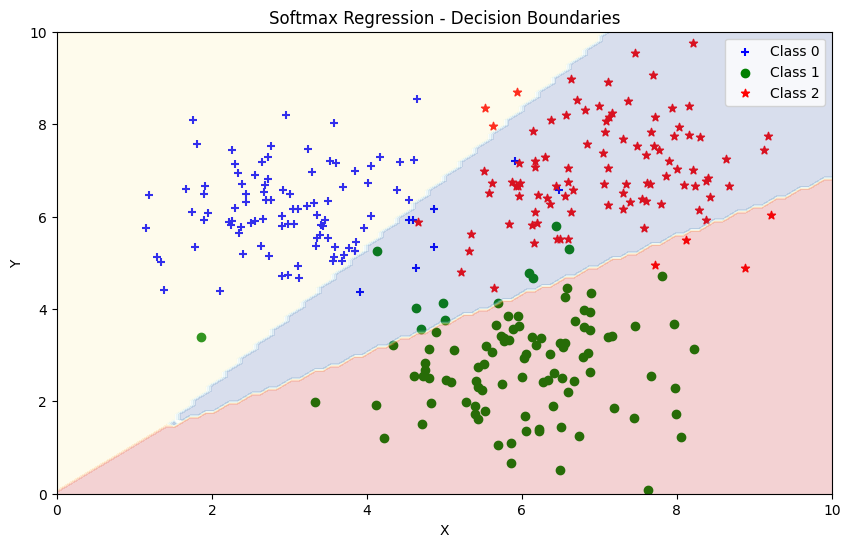


最终模型参数:
W shape: (2, 3)
W =
 [[ 0.640195   -0.90285033  0.05879714]
 [-0.8358154   0.72649276  0.08700483]]
b = [ 0.18029484  0.1328866  -0.31318158]


In [6]:
model = SoftmaxRegression()
opt = tf.keras.optimizers.SGD(learning_rate=0.01)

# 转换数据类型为float32以匹配模型参数
x_train = data_set[:, :2].astype(np.float32)
y_train = data_set[:, 2].astype(np.float32)

for i in range(500):
    loss, accuracy = train_one_step(model, opt, x_train, y_train)
    if i % 50 == 0:
        print('step: {}\t loss: {:.4f}\t accuracy: {:.3f}'.format(i, loss.numpy(), accuracy.numpy()))

# 可视化结果
plt.figure(figsize=(10, 6))
plt.scatter(C1[:, 0], C1[:, 1], c='b', marker='+', label='Class 0')
plt.scatter(C2[:, 0], C2[:, 1], c='g', marker='o', label='Class 1')
plt.scatter(C3[:, 0], C3[:, 1], c='r', marker='*', label='Class 2')

# 绘制决策边界
x_min, x_max = 0, 10
y_min, y_max = 0, 10
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
# 转换为float32以匹配模型参数
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
Z = model(grid_points)
Z = tf.argmax(Z, axis=1)
Z = Z.numpy().reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.2, cmap='RdYlBu')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Softmax Regression - Decision Boundaries')
plt.legend()
plt.show()

print('\n最终模型参数:')
print('W shape:', model.W.numpy().shape)
print('W =\n', model.W.numpy())
print('b =', model.b.numpy())

## 结果展示，无需填写代码

(10000, 2)


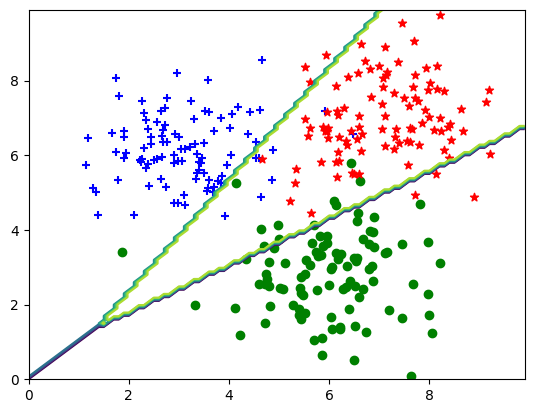

: 

In [ ]:
plt.scatter(C1[:, 0], C1[:, 1], c='b', marker='+')
plt.scatter(C2[:, 0], C2[:, 1], c='g', marker='o')
plt.scatter(C3[:, 0], C3[:, 1], c='r', marker='*')

x = np.arange(0., 10., 0.1)
y = np.arange(0., 10., 0.1)

X, Y = np.meshgrid(x, y)
inp = np.array(list(zip(X.reshape(-1), Y.reshape(-1))), dtype=np.float32)
print(inp.shape)
Z = model(inp)
Z = np.argmax(Z, axis=1)
Z = Z.reshape(X.shape)
plt.contour(X,Y,Z)
plt.show()